In [9]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

In [10]:
# Load NYSE weekly closing prices (exported from original R .Rda)

df = pd.read_csv('nyse.csv')
df.head()

,price,t
0,49.750000,1
1,51.439999,2
2,52.049999,3
3,52.279999,4
4,54.240002,5


In [11]:
# Compute weekly log returns: log_return_t = ln(P_t / P_{t-1})

df = df.sort_values('t')
df['log_price']=np.log(df['price'])
df['log_return'] = df['log_price'].diff()
df.head()

,price,t,log_price,log_return
0,49.750000,1,3.907010,NaN
1,51.439999,2,3.940416,0.033406
2,52.049999,3,3.952205,0.011789
3,52.279999,4,3.956614,0.004409
4,54.240002,5,3.993419,0.036805


In [12]:
# Create lagged return for AR(1), drop rows with no prior week

df['lag_return'] = df['log_return'].shift(1)
df = df.dropna()
df.head()

,price,t,log_price,log_return,lag_return
2,52.049999,3,3.952205,0.011789,0.033406
3,52.279999,4,3.956614,0.004409,0.011789
4,54.240002,5,3.993419,0.036805,0.004409
5,53.759998,6,3.984530,-0.008889,0.036805
6,53.389999,7,3.977623,-0.006906,-0.008889


In [13]:
# Fit AR(1) via OLS — tests weak-form EMH

emh_model = smf.ols('log_return ~ lag_return', data=df).fit()
emh_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_return   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     3.051
Date:                Tue, 21 Jul 2026   Prob (F-statistic):             0.0811
Time:                        23:01:26   Log-Likelihood:                 1677.2
No. Observations:                 689   AIC:                            -3350.
Df Residuals:                     687   BIC:                            -3341.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0016      0.001      1.934      0.053   -2.37e-05       0.003
lag_return     0.0664      0.038      1.747      0.081      -0.008       0.141
==============================================================================
Omnibus:                      153.508   Durbin-Watson:                   1.996
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1062.036
Skew:                          -0.803   Prob(JB):                    2.41e-231
Kurtosis:                       8.866   Cond. No.                         47.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [14]:
print(f"AR(1) coefficient (β1): {emh_model.params['lag_return']:.4f}")
print(f"R-squared: {emh_model.rsquared:.4f}")
print(f"p-value (β1): {emh_model.pvalues['lag_return']:.4f}")
print(f"Observations: {int(emh_model.nobs)}")

AR(1) coefficient (β1): 0.0664
R-squared: 0.0044
p-value (β1): 0.0811
Observations: 689


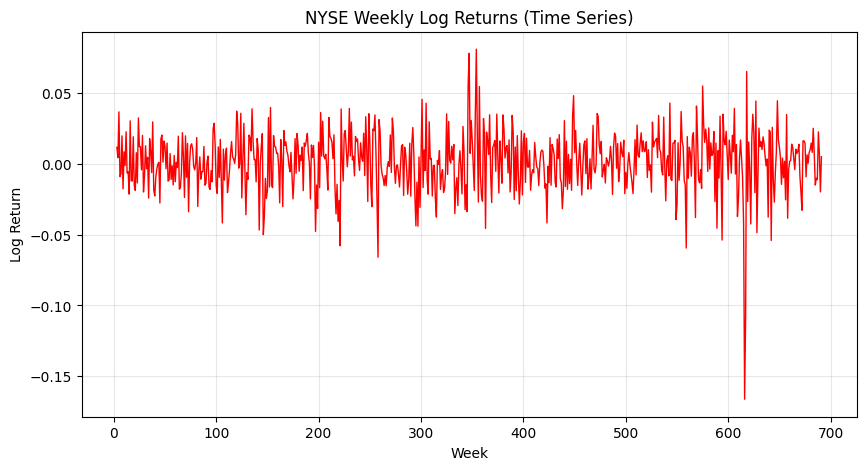

In [15]:
# Plot the return series (volatility clustering, crash spikes)

plt.figure(figsize=(10, 5))
plt.plot(df['t'],df['log_return'], color='red', linewidth=1)
plt.title('NYSE Weekly Log Returns (Time Series)')
plt.xlabel('Week')
plt.ylabel('Log Return')
plt.grid(True, alpha=0.3)
plt.show()

AR(1) test of the weak-form Efficient Markets Hypothesis on 689 weeks of NYSE returns. Python port of an analysis originally written in R, reproduces the published result (β₁ = 0.066, R² = 0.004).